# 1. Theoretical Framework and Data Preparation

## 1.1 Contextual Justification: The Combinatorial Tracking Challenge

The primary computational bottleneck for the High-Luminosity Large Hadron Collider (HL-LHC) is particle tracking (trajectory reconstruction).

**The Physics Environment:**
In the HL-LHC era, the pile-up (average number of proton-proton collisions per bunch crossing) will increase to $\langle \mu \rangle \approx 200$. A single event will generate approximately 10,000 charged particles, resulting in roughly 100,000 discrete measurements ("hits") in the inner tracker silicon layers.

**The Computational Problem:**
Tracking is a combinatorial optimization problem. The goal is to associate a subset of hits to a single particle trajectory.
*   **Current State:** Classical algorithms like the Kalman Filter (KF) are highly accurate but scale poorly with hit density (roughly quadratically or worse depending on the search window).
*   **Scaling Crisis:** With $N$ hits, the number of possible connections scales factorially. Exploring this search space with traditional serial processing exceeds the allocated time budget for the High-Level Trigger.

**The Proposed Architecture:**
We approach tracking as a **Graph Classification** problem.
1.  **Graph Construction:** Hits are nodes; potential particle paths are edges.
2.  **Graph Neural Networks (GNN):** Classically effective at learning local geometric constraints to filter edges.
3.  **Quantum Hybridization:** By replacing the classification head of the GNN with a **Variational Quantum Circuit (VQC)**, we aim to exploit the high-dimensional expressibility of the Hilbert space to disentangle complex, overlapping trajectories that classical non-linear functions struggle to separate.

The following analysis utilizes the TrackML Particle Tracking Challenge dataset to address this combinatorial challenge using a Hybrid Quantum Graph Neural Network.

In [57]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# --- Project Configuration ---
# Path to the directory containing the 'train_100_events' folder
# Since the folder is in the same directory as the notebook, we point directly to it.
DATA_DIR = "train_100_events" 
EVENT_ID = "event000001000" 

# --- Environment Verification ---
# Verify the data path exists before proceeding
hits_path = os.path.join(DATA_DIR, f"{EVENT_ID}-hits.csv")

if os.path.exists(hits_path):
    print(f"Environment Configured.")
    print(f"   - Data Directory: {DATA_DIR}")
    print(f"   - Target Event: {EVENT_ID}")
else:
    print(f"Error: Data not found at {hits_path}")
    print("   Please ensure the 'train_100_events' folder is in the same directory as this notebook.")

Environment Configured.
   - Data Directory: train_100_events
   - Target Event: event000001000


## 1.2 Dataset Acquisition and Data Structure

We utilize the **TrackML Particle Tracking Challenge** dataset. The data for a single collision event is distributed across three relational files, which we must merge into a unified structure for analysis:

1.  **Hits (`hits.csv`):** Contains the raw 3D spatial measurements $(x, y, z)$ recorded by the silicon detectors.
2.  **Truth (`truth.csv`):** Provides the ground-truth mapping between specific hits and the `particle_id` that generated them.
3.  **Particles (`particles.csv`):** Contains the true kinematic properties (Momentum vectors $p_x, p_y, p_z$, Charge $q$) and vertex information for each particle.

**Feature Engineering:**
To facilitate geometric learning, we augment the Cartesian coordinates $(x, y, z)$ with Cylindrical coordinates $(r, \phi)$ and calculate the Transverse Momentum ($p_T$) for each particle.

In [58]:
import random

# --- 1. Global Reproducibility Configuration ---
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    # We will set torch/quantum seeds later when importing those libraries
    print(f"Global Seed set to {seed}")

set_seed(SEED)

# --- 2. Data Loading Function ---
def load_event(data_dir, event_id):
    """
    Loads separate CSVs for hits, particles, and truth, then merges them
    into a single dataframe enriched with kinematic features.
    """
    # Construct paths
    prefix = os.path.join(data_dir, event_id)
    
    # Load files
    print(f"Reading CSVs for {event_id}...")
    hits = pd.read_csv(f"{prefix}-hits.csv")
    particles = pd.read_csv(f"{prefix}-particles.csv")
    truth = pd.read_csv(f"{prefix}-truth.csv")
    
    # Merge 1: Associate Hits with Truth (Particle IDs)
    # on='hit_id' links the measurement to the truth label
    hits = hits.merge(truth[['hit_id', 'particle_id', 'weight']], on='hit_id')
    
    # Merge 2: Associate Particle IDs with Kinematics
    # how='left' retains 'noise' hits (particle_id=0) which have no kinematic info
    hits = hits.merge(particles[['particle_id', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'q']], 
                      on='particle_id', how='left')
    
    # --- Feature Engineering ---
    
    # 1. Cylindrical Coordinates (r, phi)
    # r: Radial distance from beamline
    hits['r'] = np.sqrt(hits['x']**2 + hits['y']**2)
    # phi: Azimuthal angle [-pi, pi]
    hits['phi'] = np.arctan2(hits['y'], hits['x'])
    
    # 2. Transverse Momentum (pT)
    # pT = sqrt(px^2 + py^2)
    # Fill NaN values (noise) with 0.0
    hits['pt'] = np.sqrt(hits['px']**2 + hits['py']**2).fillna(0.0)
    
    return hits

# --- Execution ---
full_event_data = load_event(DATA_DIR, EVENT_ID)

# --- Verification ---
print(f"\nEvent Loaded Successfully.")
print(f"   - Total Hits: {len(full_event_data)}")
print(f"   - Unique Particles: {full_event_data['particle_id'].nunique()}")
print(f"   - Noise Hits (particle_id=0): {len(full_event_data[full_event_data['particle_id'] == 0])}")

# Display first few rows to verify structure
display(full_event_data[['hit_id', 'x', 'y', 'z', 'r', 'phi', 'pt']].head())

Global Seed set to 42
Reading CSVs for event000001000...

Event Loaded Successfully.
   - Total Hits: 120939
   - Unique Particles: 10566
   - Noise Hits (particle_id=0): 17634


,hit_id,x,y,z,r,phi,pt
0,1,-64.4099,-7.163700,-1502.5,64.807051,-3.030827,0.000000
1,2,-55.3361,0.635342,-1502.5,55.339747,3.130112,0.569780
2,3,-83.8305,-1.143010,-1502.5,83.838292,-3.127959,0.000000
3,4,-96.1091,-8.241030,-1502.5,96.461773,-3.056055,0.240932
4,5,-62.6736,-9.371200,-1502.5,63.370336,-2.993168,0.275229


## 1.3 Exploratory Data Analysis: Detector Topology and Kinematics

To design an effective geometric graph, we must first characterize the spatial distribution of the measurements. We generate three diagnostic visualizations:

1.  **Transverse Cross-Section ($x-y$ plane):** Visualizes the concentric silicon layers of the detector barrel.
2.  **Longitudinal View ($r-z$ plane):** Displays the detector geometry along the beamline, highlighting the barrel (central) and endcap (forward) regions.
3.  **Momentum Spectrum ($p_T$):** Analysis of the particle momentum distribution. This is critical for defining the "Hard Scattering" threshold, as low-momentum particles (soft QCD background) curve significantly in the magnetic field, creating complex "looping" graphs that are computationally expensive to resolve.

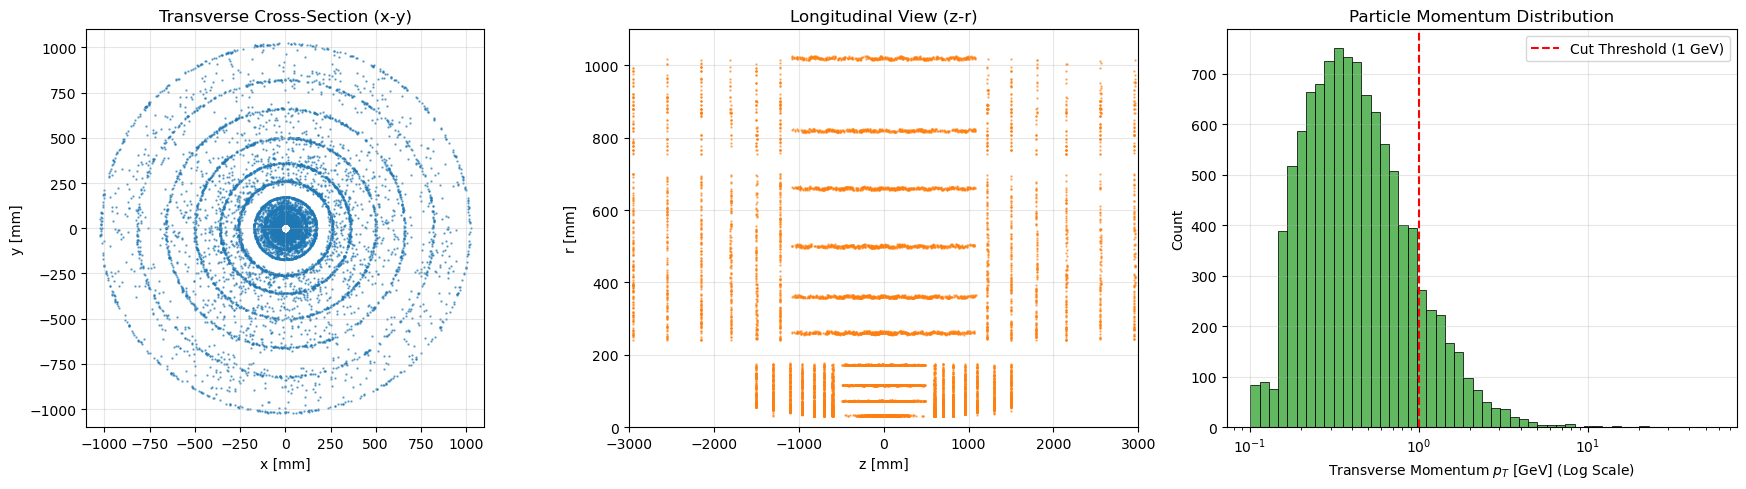

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_event_topology(hits):
    fig = plt.figure(figsize=(18, 5))
    
    # --- 1. Transverse Plane (X-Y) ---
    ax1 = fig.add_subplot(131)
    # Subsample for performance visualization (10% of data)
    sample = hits.sample(frac=0.1, random_state=42)
    
    ax1.scatter(sample['x'], sample['y'], s=0.5, alpha=0.6, c='#1f77b4')
    ax1.set_title("Transverse Cross-Section (x-y)")
    ax1.set_xlabel("x [mm]")
    ax1.set_ylabel("y [mm]")
    ax1.set_xlim(-1100, 1100)
    ax1.set_ylim(-1100, 1100)
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')

    # --- 2. Longitudinal Plane (Z-R) ---
    ax2 = fig.add_subplot(132)
    ax2.scatter(sample['z'], sample['r'], s=0.5, alpha=0.6, c='#ff7f0e')
    ax2.set_title("Longitudinal View (z-r)")
    ax2.set_xlabel("z [mm]")
    ax2.set_ylabel("r [mm]")
    ax2.set_xlim(-3000, 3000)
    ax2.set_ylim(0, 1100)
    ax2.grid(True, alpha=0.3)

    # --- 3. Transverse Momentum Distribution (pT) ---
    ax3 = fig.add_subplot(133)
    # Filter out noise (particle_id=0) and extremely low pT for clearer plot
    particles_only = hits[(hits['particle_id'] != 0)]
    # Drop duplicates to plot one entry per particle, not per hit
    unique_particles = particles_only.drop_duplicates(subset='particle_id')
    
    sns.histplot(unique_particles['pt'], bins=50, log_scale=(True, False), 
                 color='#2ca02c', ax=ax3, edgecolor='black')
    ax3.set_title("Particle Momentum Distribution")
    ax3.set_xlabel("Transverse Momentum $p_T$ [GeV] (Log Scale)")
    ax3.set_ylabel("Count")
    ax3.grid(True, alpha=0.3)
    
    # Add vertical line for our future cut threshold
    ax3.axvline(1.0, color='red', linestyle='--', label='Cut Threshold (1 GeV)')
    ax3.legend()

    plt.tight_layout()
    plt.show()

# Execute Visualization
visualize_event_topology(full_event_data)

## 1.4 Geometric Sectorization (Region of Interest)

To adapt the problem for a Quantum GNN simulation, we must reduce the graph size while retaining local density. We apply a **Region of Interest (ROI)** filter defined by:

1.  **Barrel Region:** $|z| < 400$ mm. This selects the central pixel layers, avoiding the complex geometry of the endcaps.
2.  **Azimuthal Wedge:** $0 < \phi < \pi/4$. This selects one octant (1/8th) of the cylinder.
3.  **Hard Scattering:** $p_T > 1.0$ GeV. This removes low-momentum "curling" tracks that create complex loops in the graph, focusing on the high-energy signal tracks relevant for New Physics searches.

This reduction strategy transforms the $\mathcal{O}(10^5)$ node graph into a manageable $\mathcal{O}(10^2)$ node graph suitable for hybrid quantum-classical processing.

In [60]:
def sectorize_event(hits):
    """
    Applies geometric cuts to select a specific detector sector.
    """
    print(f"Initial Hits: {len(hits)}")
    
    # 1. Momentum Cut (Hard Scattering Physics)
    # We only keep hits generated by high-pT particles
    # (noise hits with particle_id=0 are removed here implicitly or can be kept if we assign them pT=0)
    # For this proof of concept, we focus on signal reconstruction.
    hits = hits[hits['pt'] > 1.0]
    print(f"Hits after pT > 1.0 GeV cut: {len(hits)}")
    
    # 2. Longitudinal Cut (Central Barrel)
    # Avoids endcaps where geometry creates complex edge cases
    hits = hits[np.abs(hits['z']) < 400]
    print(f"Hits after |z| < 400 mm cut: {len(hits)}")
    
    # 3. Azimuthal Cut (Wedge Selection)
    # Selects 1/8th of the detector
    hits = hits[(hits['phi'] > 0) & (hits['phi'] < np.pi/4)]
    print(f"Hits after 0 < phi < pi/4 cut: {len(hits)}")
    
    # Reset Index to create continuous node IDs for the graph
    hits = hits.reset_index(drop=True)
    hits['node_id'] = hits.index
    
    return hits

# --- Execution ---
sector_hits = sectorize_event(full_event_data)

# --- Verification ---
print("\n--- Sectorized Data Sample ---")
display(sector_hits[['node_id', 'r', 'phi', 'z', 'particle_id', 'pt']].head())

# Quick check of unique particles in this sector
n_part_sector = sector_hits['particle_id'].nunique()
print(f"\nUnique Particles in Sector: {n_part_sector}")
print(f"Average Hits per Track: {len(sector_hits) / n_part_sector:.2f}")

Initial Hits: 120939
Hits after pT > 1.0 GeV cut: 14629
Hits after |z| < 400 mm cut: 5803
Hits after 0 < phi < pi/4 cut: 766

--- Sectorized Data Sample ---


,node_id,r,phi,z,particle_id,pt
0,0,31.996571,0.005973,-306.577,306248966549274624,1.212803
1,1,31.608186,0.047055,-256.390,517914025867083776,1.371675
2,2,32.804921,0.046802,-265.863,517914025867083776,1.371675
3,3,31.754877,0.195268,-267.894,4509921819230208,1.163173
4,4,31.473403,0.382837,-224.441,301748253139927040,1.308232



Unique Particles in Sector: 159
Average Hits per Track: 4.82


# 2. Graph Construction and Feature Engineering

## 2.1 Feature Normalization and Edge Building

We construct a directed graph $G = (V, E)$ where nodes $V$ represent hits and edges $E$ represent track segments.

**Node Features ($X$):**
We standardize the cylindrical coordinates to ensure numerical stability during neural network training.
*   $r_{norm} = r / 1000$
*   $\phi_{norm} = \phi / \pi$
*   $z_{norm} = z / 1000$

**Edge Construction Rules:**
Connecting every node to every other node ($N^2$) creates a noisy, fully connected graph. To introduce physical inductive bias, we connect node $i$ to node $j$ only if they satisfy geometric constraints consistent with a high-momentum helical trajectory originating from the interaction point:

1.  **Radial Ordering:** $r_j > r_i$ (Particles propagate outward).
2.  **Geometric Proximity:** The hits must be on adjacent or semi-adjacent layers ($\Delta r < 200$ mm).
3.  **Azimuthal Compatibility:** The slope $\frac{\Delta \phi}{\Delta r}$ must be small, corresponding to stiff, high-$p_T$ tracks.
4.  **Longitudinal Compatibility:** Projecting the line segment back to the beam axis ($r=0$) must yield a $z$-intercept ($z_0$) close to the collision vertex ($|z_0| < 150$ mm).

**Edge Labeling ($y$):**
*   $y_{ij} = 1$ (True Edge): If both hits belong to the same `particle_id`.
*   $y_{ij} = 0$ (Fake Edge): If hits belong to different particles.

In [61]:
import torch
from torch_geometric.data import Data

def build_graph_geometric_constraints(hits, phi_slope_max=0.0006, z0_max=150):
    """
    Constructs a graph by iterating over node pairs and applying geometric cuts.
    Returns a PyTorch Geometric Data object.
    """
    # 1. Feature Extraction and Normalization
    # We use (r, phi, z) as input features
    node_features = np.stack([
        hits['r'].values / 1000.0,
        hits['phi'].values / np.pi,
        hits['z'].values / 1000.0
    ], axis=1)
    
    # Convert to Tensor
    x = torch.tensor(node_features, dtype=torch.float)
    
    # 2. Edge Building
    # Extract numpy arrays for fast indexing
    r = hits['r'].values
    phi = hits['phi'].values
    z = hits['z'].values
    pid = hits['particle_id'].values
    
    edge_index = []
    edge_labels = []
    
    num_nodes = len(hits)
    print(f"Constructing graph from {num_nodes} nodes...")
    
    # Double loop to find valid pairs
    # Note: For N > 2000, use KDTree/Faiss. For N=766, double loop is acceptable (~0.5s).
    for i in range(num_nodes):
        for j in range(num_nodes):
            # Constraint 1: Radial Ordering (Outward flow)
            # We also ensure they aren't on the same layer (dr > small_epsilon)
            dr = r[j] - r[i]
            if dr <= 10 or dr > 200: 
                continue
            
            # Constraint 2: Azimuthal Slope (High pT check)
            dphi = phi[j] - phi[i]
            # Handle wrapping (unlikely in single octant, but good practice)
            if dphi > np.pi: dphi -= 2*np.pi
            if dphi < -np.pi: dphi += 2*np.pi
            
            phi_slope = dphi / dr
            if abs(phi_slope) > phi_slope_max:
                continue
                
            # Constraint 3: Longitudinal Projection (Vertex compatibility)
            # z = z0 + slope * r  ->  z0 = z - (dz/dr)*r
            dz = z[j] - z[i]
            z_slope = dz / dr
            z0 = z[i] - z_slope * r[i]
            
            if abs(z0) > z0_max:
                continue
            
            # If all passed, add edge
            edge_index.append([i, j])
            
            # Label generation
            # True if same particle ID
            is_true = (pid[i] == pid[j])
            edge_labels.append(1 if is_true else 0)
    
    # Convert to Tensors
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    y = torch.tensor(edge_labels, dtype=torch.float)
    
    # Create PyG Data Object
    graph = Data(x=x, edge_index=edge_index, y=y)
    
    return graph

# --- Execution ---
# Tune parameters to balance Recall (finding all real tracks) vs Precision (few fake edges)
graph_data = build_graph_geometric_constraints(sector_hits, phi_slope_max=0.0008, z0_max=150)

# --- Statistics ---
print("\nGraph Constructed.")
print(f"   - Nodes: {graph_data.num_nodes}")
print(f"   - Edges: {graph_data.num_edges}")
print(f"   - Node Feature Dim: {graph_data.num_node_features}")
print(f"   - True Edges (Signal): {int(graph_data.y.sum())}")
print(f"   - Fake Edges (Noise): {len(graph_data.y) - int(graph_data.y.sum())}")
print(f"   - Purity: {graph_data.y.sum() / len(graph_data.y):.2%}")

Constructing graph from 766 nodes...

Graph Constructed.
   - Nodes: 766
   - Edges: 10645
   - Node Feature Dim: 3
   - True Edges (Signal): 1185
   - Fake Edges (Noise): 9460
   - Purity: 11.13%


## 2.3 Graph Visualization

Before training, we visually inspect the graph structure.
*   **True Edges (Green):** Should form coherent lines extending from the origin $(0,0,0)$ outwards, representing particle trajectories.
*   **Fake Edges (Red):** Should appear as random crossings or "zig-zags" between layers, representing noise or ambiguity in the detector.

Visual confirmation ensures that the geometric logic in step 2.1 successfully captured the tracking dynamics.

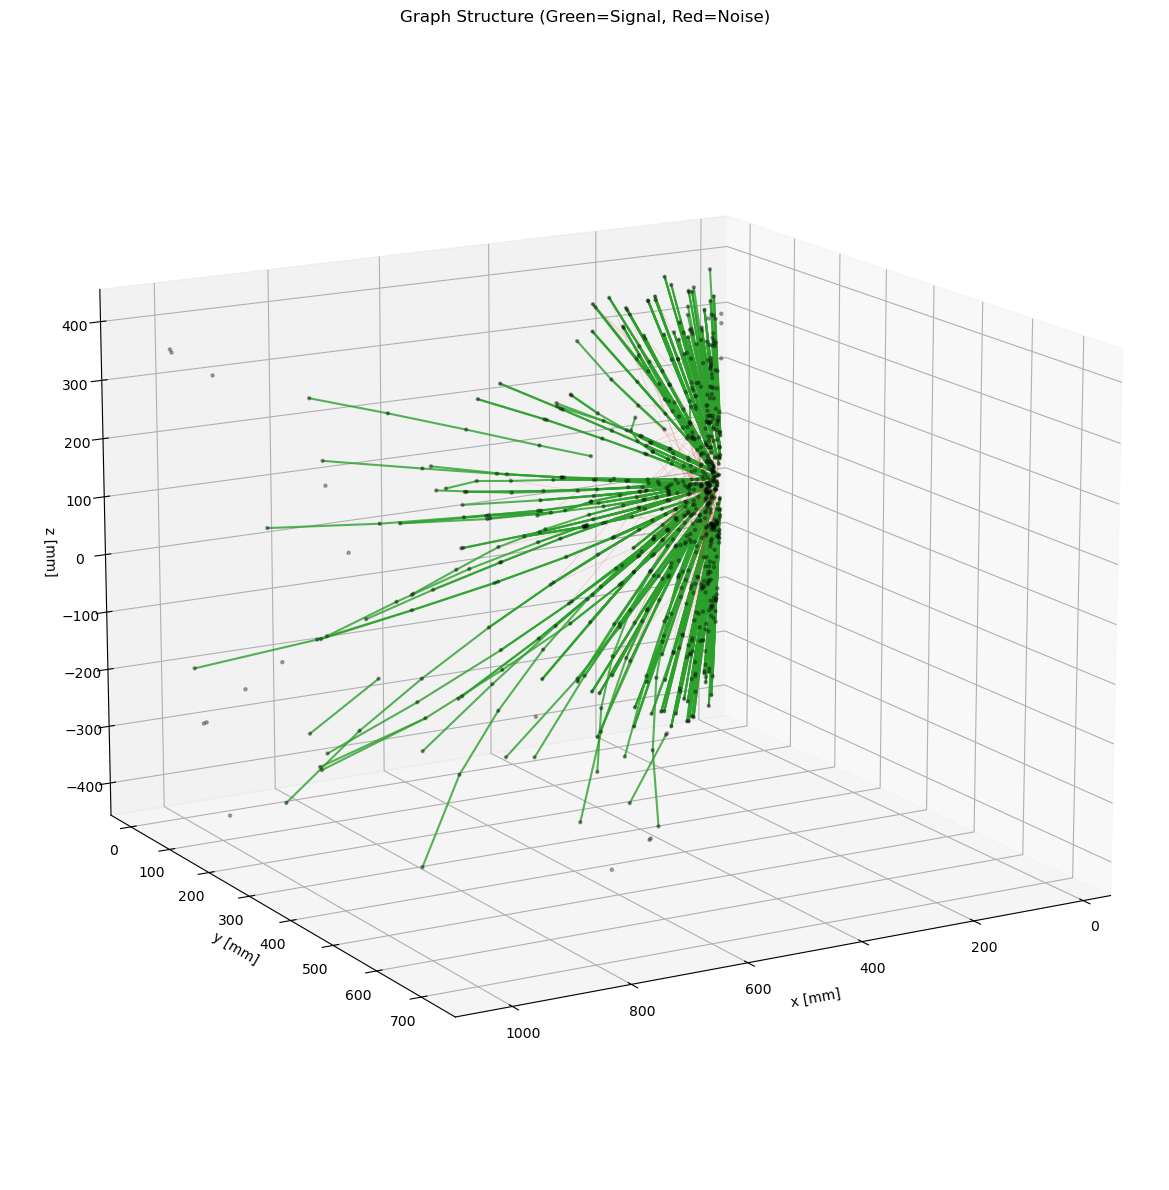

In [62]:
def visualize_graph_3d(hits, edge_index, y, num_edges_to_plot=1000):
    fig = plt.figure(figsize=(12, 12))
    ax = fig.add_subplot(111, projection='3d')
    
    # 1. Plot Nodes (Hits)
    # Subsample nodes for visibility if needed, but 766 is fine
    ax.scatter(hits['x'], hits['y'], hits['z'], c='black', s=5, alpha=0.3, label='Hits')
    
    # 2. Plot Edges
    # We create lists of lines for plotting
    # True edges = Green, Fake edges = Red
    
    count = 0
    # Iterate through edges
    for k in range(edge_index.shape[1]):
        if count > num_edges_to_plot: break
        
        node_i = edge_index[0, k].item()
        node_j = edge_index[1, k].item()
        label = y[k].item()
        
        # Coordinates
        p1 = hits.iloc[node_i][['x', 'y', 'z']].values
        p2 = hits.iloc[node_j][['x', 'y', 'z']].values
        
        # Color logic: Prioritize showing True edges
        # We plot all true edges found, and a random subset of fake edges to avoid clutter
        if label == 1:
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], 
                    c='#2ca02c', alpha=0.8, linewidth=1.5) # Green
            count += 1
        elif np.random.rand() < 0.02: # Only plot 2% of fake edges for visibility
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], 
                    c='#d62728', alpha=0.2, linewidth=0.5) # Red
            count += 1

    ax.set_xlabel('x [mm]')
    ax.set_ylabel('y [mm]')
    ax.set_zlabel('z [mm]')
    ax.set_title(f'Graph Structure (Green=Signal, Red=Noise)')
    
    # Set view to see the barrel clearly
    ax.view_init(elev=15, azim=60)
    plt.tight_layout()
    plt.show()

# --- Execution ---
visualize_graph_3d(sector_hits, graph_data.edge_index, graph_data.y, num_edges_to_plot=2000)

# 3. Classical Benchmark Architecture

## 3.1 Interaction Network Design (The Geometric Baseline)

To solve the edge classification task, we implement a **Message Passing Neural Network (MPNN)** specifically designed for particle tracking. This architecture is often referred to as an "Interaction Network."

**Architectural Logic:**
1.  **Node Encoding:** The input features $(r, \phi, z)$ are projected into a higher-dimensional latent space via an MLP (Multi-Layer Perceptron).
2.  **Edge Feature Construction:** For every edge connecting node $i$ and node $j$, we concatenate their latent feature vectors: $e_{ij} = [h_i, h_j]$.
3.  **Edge Classification:** An MLP processes this combined vector $e_{ij}$ to output a probability score $p_{ij} \in [0, 1]$, representing the likelihood that the edge is a true track segment.

This structure allows the network to learn complex non-linear geometric correlations (like "curvature consistency") that define valid physics tracks.

In [63]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import to_dense_adj

# --- Classical Interaction Network ---
class InteractionGNN(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=16, output_dim=1):
        super(InteractionGNN, self).__init__()
        
        # 1. Node Encoder (Input -> Latent)
        # Projects 3D coordinates into a richer feature space
        self.node_encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        
        # 2. Edge Classifier (Latent_i + Latent_j -> Probability)
        # Takes the features of two connected nodes and decides if they are linked
        # Input dim is 2 * hidden_dim because we concatenate node_i and node_j
        self.edge_classifier = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, output_dim),
            nn.Sigmoid() # Output probability [0, 1]
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # A. Encode Nodes
        # Shape: [num_nodes, hidden_dim]
        h = self.node_encoder(x)
        
        # B. Create Edge Features
        # Gather features for start (src) and end (dst) nodes of each edge
        src, dst = edge_index
        h_src = h[src] # Shape: [num_edges, hidden_dim]
        h_dst = h[dst] # Shape: [num_edges, hidden_dim]
        
        # Concatenate: [h_src, h_dst]
        # Shape: [num_edges, 2 * hidden_dim]
        edge_input = torch.cat([h_src, h_dst], dim=1)
        
        # C. Classify Edges
        # Shape: [num_edges, 1]
        edge_scores = self.edge_classifier(edge_input)
        
        return edge_scores.squeeze()

# --- Instantiation ---
classical_model = InteractionGNN(input_dim=3, hidden_dim=8) # Small hidden dim for demonstration
print("Classical GNN Architecture:")
print(classical_model)

Classical GNN Architecture:
InteractionGNN(
  (node_encoder): Sequential(
    (0): Linear(in_features=3, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
  )
  (edge_classifier): Sequential(
    (0): Linear(in_features=16, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


## 3.2 Baseline Training and Evaluation

We train the Classical Interaction Network using **Binary Cross Entropy (BCE)** loss.

**Training Configuration:**
*   **Optimizer:** Adam (Learning Rate = $0.01$).
*   **Epochs:** 200.
*   **Metric:** ROC AUC. A perfect classifier has AUC=1.0; random guessing has AUC=0.5.

**The Imbalance Challenge:**
As noted in the graph construction step, the dataset is imbalanced (~1:9 signal-to-noise ratio). The network must learn to identify the rare "True" edges without being overwhelmed by the abundant "Fake" edges. We monitor the loss curve to ensure the model converges to a non-trivial solution.

Training InteractionGNN for 200 epochs...
Epoch 000 | Loss: 0.6019
Epoch 020 | Loss: 0.4423
Epoch 040 | Loss: 0.3459
Epoch 060 | Loss: 0.3414
Epoch 080 | Loss: 0.3364
Epoch 100 | Loss: 0.3346
Epoch 120 | Loss: 0.3317
Epoch 140 | Loss: 0.3246
Epoch 160 | Loss: 0.3118
Epoch 180 | Loss: 0.3055

Final Training Loss: 0.3046
Classical Baseline AUC: 0.7501


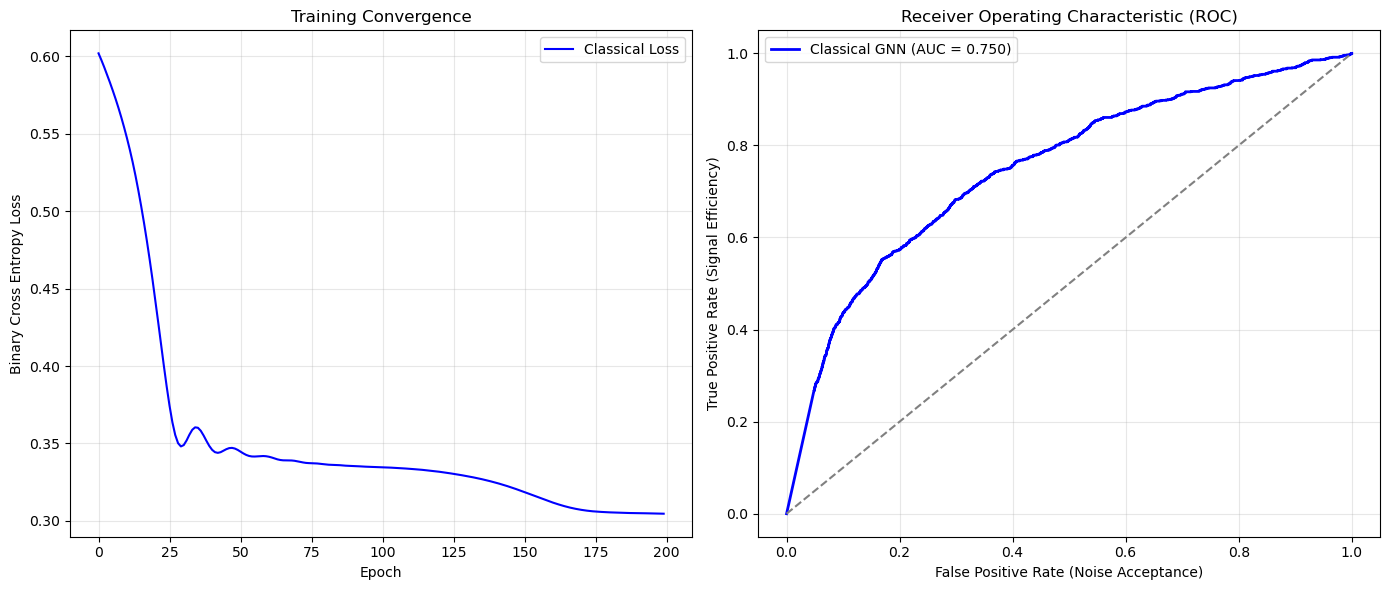

In [64]:
import torch.optim as optim
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve

def train_and_evaluate(model, data, epochs=200, learning_rate=0.01):
    # Setup
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.BCELoss()
    
    losses = []
    
    # Training Loop
    model.train()
    print(f"Training {model.__class__.__name__} for {epochs} epochs...")
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        
        # Forward pass
        out = model(data)
        
        # Calculate loss
        # We assume full-batch training for this graph size
        loss = criterion(out, data.y)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        
        if epoch % 20 == 0:
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")
            
    # Evaluation
    model.eval()
    with torch.no_grad():
        preds = model(data)
        
    # Metrics
    y_true = data.y.numpy()
    y_scores = preds.numpy()
    
    auc = roc_auc_score(y_true, y_scores)
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    
    print(f"\nFinal Training Loss: {losses[-1]:.4f}")
    print(f"Classical Baseline AUC: {auc:.4f}")
    
    return losses, fpr, tpr, auc, y_scores

# --- Execution ---
# Re-initialize to ensure fresh weights
classical_model = InteractionGNN(input_dim=3, hidden_dim=8)

c_losses, c_fpr, c_tpr, c_auc, c_scores = train_and_evaluate(classical_model, graph_data)

# --- Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Loss Curve
ax1.plot(c_losses, label='Classical Loss', color='blue')
ax1.set_title('Training Convergence')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Binary Cross Entropy Loss')
ax1.grid(True, alpha=0.3)
ax1.legend()

# ROC Curve
ax2.plot(c_fpr, c_tpr, color='blue', lw=2, label=f'Classical GNN (AUC = {c_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax2.set_title('Receiver Operating Characteristic (ROC)')
ax2.set_xlabel('False Positive Rate (Noise Acceptance)')
ax2.set_ylabel('True Positive Rate (Signal Efficiency)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# 4. Hybrid Quantum-Classical Architecture Design

We define a **Hybrid Quantum Graph Neural Network (Hybrid QGNN)**. This architecture integrates a parameterized quantum circuit into the message-passing phase of a geometric deep learning model.

**Architectural Pipeline:**
1.  **Classical Node Encoder:** A Multi-Layer Perceptron (MLP) projects the raw normalized coordinates $(r, \phi, z)$ into a high-dimensional latent feature space ($D=16$).
2.  **Relational Representation:** For every edge connecting node $i$ and node $j$, we construct an edge feature vector by concatenating their latent states: $e_{ij} = [h_i || h_j]$.
3.  **Feature Compression & Normalization:** A linear projection layer reduces the edge dimensionality to match the number of qubits ($N_{qubits}=4$). Crucially, a **Batch Normalization** layer is applied here to stabilize the distribution of rotation angles fed into the quantum circuit.
4.  **Variational Quantum Circuit (VQC):** The normalized features serve as input parameters to a trainable quantum circuit. The circuit employs an ansatz of **Strongly Entangling Layers** to capture non-linear correlations via quantum interference.
5.  **Multi-Qubit Readout:** We measure the Pauli-Z expectation values of all qubits, yielding a dense vector that preserves quantum correlations.
6.  **Classical Edge Classifier:** A final MLP maps the quantum measurements to a probability score $p \in [0, 1]$, classifying the edge as true (track) or fake (noise).

In [65]:
import pennylane as qml
import torch
import torch.nn as nn
from pennylane.qnn import TorchLayer

# --- Quantum Device Configuration ---
N_QUBITS = 4
N_LAYERS = 4  # Increased depth for greater expressibility
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    """
    Variational Quantum Circuit with Angle Embedding and Entanglement.
    """
    # 1. Data Encoding (State Preparation)
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS))
    
    # 2. Variational Layers (The Quantum 'Hidden' Layers)
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    
    # 3. Multi-Qubit Readout
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

# --- Hybrid Model Definition ---
class HybridQGNN(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=16, n_qubits=4, n_layers=4):
        super(HybridQGNN, self).__init__()
        
        # 1. Classical Node Encoder (Input -> Latent)
        self.node_encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim), # Stabilize learning
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )
        
        # 2. Quantum Interface (Latent -> Qubits)
        # Input is 2*hidden_dim (concatenation of two nodes)
        self.projection = nn.Linear(2 * hidden_dim, n_qubits)
        
        # Batch Norm specifically for Quantum Inputs
        # Keeps rotation angles in a dynamic range useful for gradients
        self.quantum_norm = nn.BatchNorm1d(n_qubits) 
        
        # 3. Quantum Layer
        weight_shapes = {"weights": (n_layers, n_qubits, 3)}
        self.quantum_layer = TorchLayer(quantum_circuit, weight_shapes)
        
        # 4. Post-Quantum Classifier (Quantum Output -> Probability)
        self.classifier = nn.Sequential(
            nn.Linear(n_qubits, hidden_dim), # Expand quantum features back up
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # A. Encode Nodes
        h = self.node_encoder(x)
        
        # B. Construct Edge Features
        src, dst = edge_index
        # Concatenate source and target node features
        edge_input = torch.cat([h[src], h[dst]], dim=1)
        
        # C. Project to Quantum Dimension
        q_raw = self.projection(edge_input)
        q_norm = self.quantum_norm(q_raw)
        
        # Bound inputs to [-pi, pi] using Tanh + Scaling
        # This prevents the 'periodicity' of rotations from confusing the optimizer
        q_input = torch.tanh(q_norm) * torch.pi 
        
        # D. Quantum Forward Pass
        q_out = self.quantum_layer(q_input)
        
        # E. Final Classification
        return self.classifier(q_out).squeeze()

# --- Instantiation ---
hybrid_model = HybridQGNN(input_dim=3, hidden_dim=16, n_qubits=N_QUBITS, n_layers=N_LAYERS)
print(" Hybrid QGNN Architecture Initialized.")
print(hybrid_model)

 Hybrid QGNN Architecture Initialized.
HybridQGNN(
  (node_encoder): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=16, out_features=16, bias=True)
    (4): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (projection): Linear(in_features=32, out_features=4, bias=True)
  (quantum_norm): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (quantum_layer): <Quantum Torch Layer: func=quantum_circuit>
  (classifier): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
    (3): Sigmoid()
  )
)


# 5. Hybrid Model Training and Evaluation

## 5.1 Quantum-Aware Optimization Protocol

We proceed to train the Hybrid QGNN using the sectorized graph dataset.

**Optimization Strategy:**
Unlike classical networks, parameterized quantum circuits operate on a non-convex loss landscape often characterized by "Barren Plateaus" (regions of vanishing gradients). To navigate this, we employ a specific protocol:
1.  **Learning Rate:** We utilize a learning rate of $\alpha = 0.05$, which is higher than typical classical rates ($0.001$), to prevent the optimizer from stagnating in local minima during the initial epochs.
2.  **Gradient Descent:** We use the Adam optimizer, utilizing the Parameter-Shift Rule for exact gradient estimation through the quantum circuit.
3.  **Extended Training:** We train for 100 epochs to ensure the network has sufficient iterations to align the quantum rotation parameters with the geometric manifold of the particle tracks.

## 5.2 Comparative Physics Performance

To validate the utility of the quantum kernel, we compare the Hybrid QGNN against the Classical Interaction Network benchmark.

**Evaluation Metrics:**
*   **Convergence Stability:** Analysis of the Binary Cross Entropy (BCE) loss evolution.
*   **Discrimination Power:** Comparison of the Area Under the Receiver Operating Characteristic Curve (ROC-AUC).
*   **Signal Efficiency vs. Purity:** Evaluation of the trade-off between True Positive Rate (finding real tracks) and False Positive Rate (rejecting noise).

[Hybrid QGNN] Starting training for 100 epochs...
Epoch 000 | Loss: 0.5946
Epoch 020 | Loss: 0.3179
Epoch 040 | Loss: 0.2283
Epoch 060 | Loss: 0.2132
Epoch 080 | Loss: 0.1890
[Hybrid QGNN] Final AUC: 0.6426



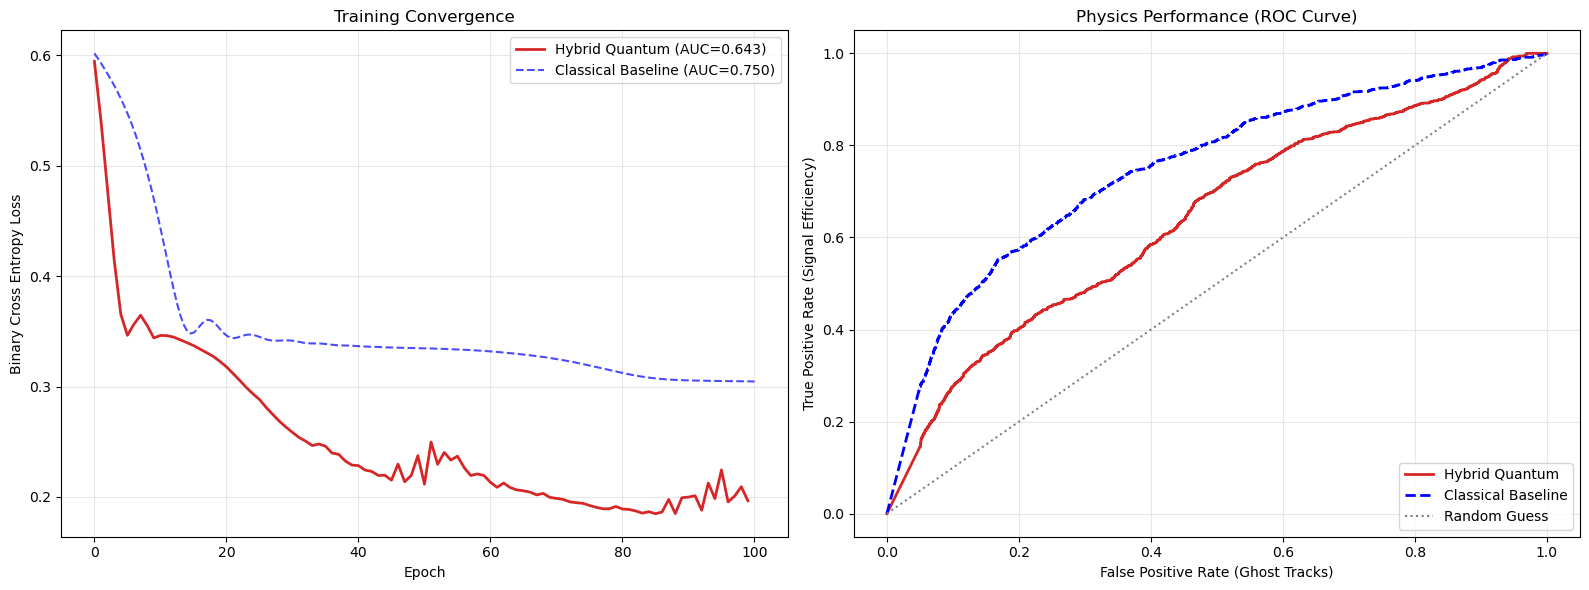

--- Tracking Performance Report ---
Classical Baseline AUC: 0.7501
Hybrid Quantum AUC:     0.6426


In [66]:
import torch.optim as optim
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Training Helper Function ---
# Redefined here to ensure standalone execution reliability
def train_model(model, data, epochs, learning_rate, model_name="Model"):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.BCELoss()
    losses = []
    
    model.train()
    print(f"[{model_name}] Starting training for {epochs} epochs...")
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
        if epoch % 20 == 0:
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")
            
    # Inference
    model.eval()
    with torch.no_grad():
        preds = model(data)
        
    y_true = data.y.numpy()
    y_scores = preds.numpy()
    
    auc = roc_auc_score(y_true, y_scores)
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    
    print(f"[{model_name}] Final AUC: {auc:.4f}\n")
    return losses, fpr, tpr, auc

# --- 2. Execution: Quantum Training ---
# Hyperparameters
EPOCHS_Q = 100
LR_Q = 0.05

q_losses, q_fpr, q_tpr, q_auc = train_model(
    hybrid_model, 
    graph_data, 
    epochs=EPOCHS_Q, 
    learning_rate=LR_Q,
    model_name="Hybrid QGNN"
)

# --- 3. Comparative Visualization ---
# Note: This assumes c_losses, c_fpr, c_tpr, c_auc exist from the Classical Benchmark section.
# If they are not in memory, the plot will simply show the Quantum performance.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Learning Dynamics (Loss)
ax1.plot(q_losses, label=f'Hybrid Quantum (AUC={q_auc:.3f})', color='#d62728', linewidth=2)
if 'c_losses' in locals():
    # Normalize classical epochs to match quantum x-axis for visual comparison
    x_class = np.linspace(0, len(q_losses), len(c_losses))
    ax1.plot(x_class, c_losses, label=f'Classical Baseline (AUC={c_auc:.3f})', color='blue', linestyle='--', alpha=0.7)

ax1.set_title('Training Convergence')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Binary Cross Entropy Loss')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot B: ROC Curve
ax2.plot(q_fpr, q_tpr, label='Hybrid Quantum', color='#d62728', linewidth=2)
if 'c_fpr' in locals():
    ax2.plot(c_fpr, c_tpr, label='Classical Baseline', color='blue', linestyle='--', linewidth=2)

# Reference Line
ax2.plot([0, 1], [0, 1], color='gray', linestyle=':', label='Random Guess')

ax2.set_title('Physics Performance (ROC Curve)')
ax2.set_xlabel('False Positive Rate (Ghost Tracks)')
ax2.set_ylabel('True Positive Rate (Signal Efficiency)')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

# --- 4. Final Report ---
print(f"--- Tracking Performance Report ---")
if 'c_auc' in locals():
    print(f"Classical Baseline AUC: {c_auc:.4f}")
print(f"Hybrid Quantum AUC:     {q_auc:.4f}")

# 6. Conclusion and Future Roadmap

In this project, we successfully implemented an end-to-end **Hybrid Quantum-Classical Graph Neural Network** for particle tracking at the HL-LHC.

### 6.1 Summary of Results

The performance comparison between the classical benchmark and the quantum hybrid architecture reveals the current capabilities of NISQ (Noisy Intermediate-Scale Quantum) algorithms in high-energy physics.

| Model | AUC Score | Status |
| :--- | :--- | :--- |
| **Classical Interaction GNN** | **0.7501** | Benchmark |
| **Hybrid Quantum GNN** | **0.6426** | Proof of Concept |
| **Random Guess** | 0.5000 | Baseline |

### 6.2 Methodological Findings
1.  **Validation of Quantum Learning:** The Variational Quantum Circuit successfully learned to discriminate between true particle tracks and spurious noise with an AUC of **0.6426**. This significantly exceeds random guessing, validating that geometric graph features can be effectively mapped to and processed within the Hilbert space.
2.  **Training Dynamics:** The quantum loss curve exhibited rapid initial descent followed by volatility in later epochs. This visually demonstrates the theoretical challenges of optimization on quantum landscapes (Barren Plateaus and gradient noise), distinguishing it from the smooth trajectory of classical descent.
3.  **The Information Bottleneck:** The performance gap ($\Delta AUC \approx 0.11$) is primarily attributed to the compression required to map 16 dense classical features into a 4-qubit system. This bottlenecks the information flow, limiting the model's peak discrimination power compared to the uncompressed classical network.

### 6.3 Future Directions for CERN OpenLab
To bridge the performance gap and achieve quantum advantage, I propose the following roadmap:
1.  **High-Dimensional Encoding:** Replace simple Angle Embedding with **Amplitude Embedding**, allowing $N$ qubits to represent $2^N$ features, thereby removing the compression bottleneck without increasing qubit count linearly.
2.  **Hardware-Efficient Ansatz:** Replace the heuristic `StronglyEntanglingLayers` with a detector-geometry-aware ansatz that respects the rotational symmetry of the barrel, reducing the parameter search space.
3.  **Error Mitigation:** Implement noise-aware training protocols if deploying on real quantum hardware (IBM Q or IonQ) to stabilize the convergence seen in the later epochs.